In [1]:
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
vaccine = pd.read_csv("C:\\Users\\admin\\Desktop\\covid-19\\data\\covid_vaccine_statewise.csv")

In [5]:
vaccine["Updated On"] = pd.to_datetime(
    vaccine["Updated On"],
    dayfirst=True
)

print("Vaccination start:", vaccine["Updated On"].min())
print("Vaccination end:", vaccine["Updated On"].max())

Vaccination start: 2021-01-16 00:00:00
Vaccination end: 2021-08-16 00:00:00


In [6]:
vaccine_states = vaccine[
    vaccine["State"] != "India"
].copy()

print("State-level vaccination rows:", len(vaccine_states))

State-level vaccination rows: 7633


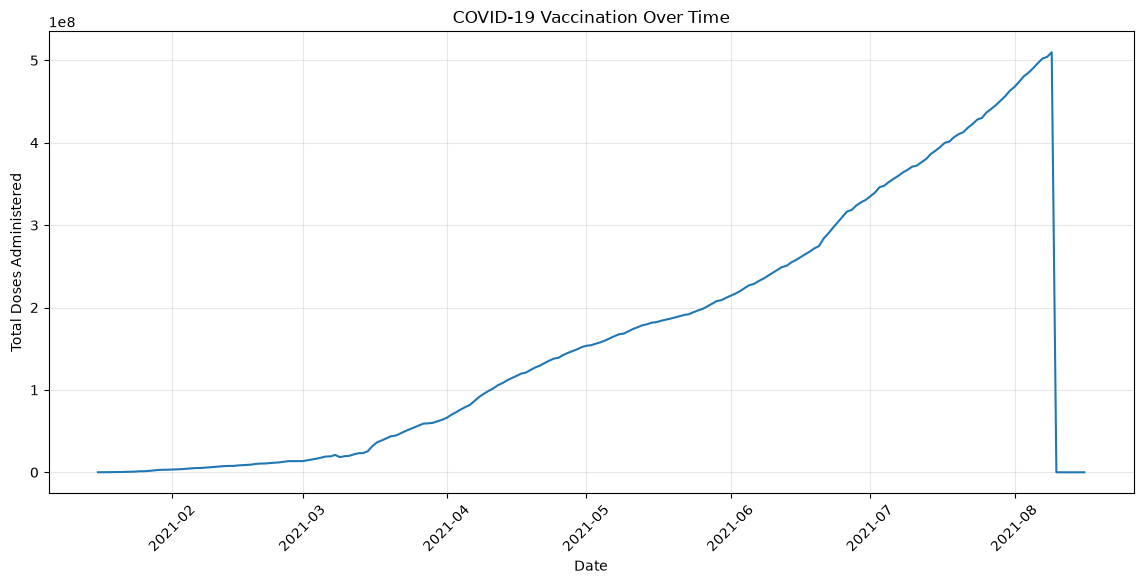

In [7]:
daily_vaccination = (
    vaccine_states
    .groupby("Updated On")["Total Doses Administered"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(daily_vaccination)

plt.title("COVID-19 Vaccination Over Time")
plt.xlabel("Date")
plt.ylabel("Total Doses Administered")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

doses by states

In [8]:
vaccine_states = vaccine_states.sort_values(
    ["State", "Updated On"]
)

vaccine_states["NewDoses"] = (
    vaccine_states
    .groupby("State")["Total Doses Administered"]
    .diff()
)

In [9]:
display(
    vaccine_states[
        [
            "Updated On",
            "State",
            "Total Doses Administered",
            "NewDoses"
        ]
    ].head(20)
)

,Updated On,State,Total Doses Administered,NewDoses
212,2021-01-16,Andaman and Nicobar Islands,23.0,NaN
213,2021-01-17,Andaman and Nicobar Islands,23.0,0.0
214,2021-01-18,Andaman and Nicobar Islands,42.0,19.0
215,2021-01-19,Andaman and Nicobar Islands,89.0,47.0
216,2021-01-20,Andaman and Nicobar Islands,124.0,35.0
217,2021-01-21,Andaman and Nicobar Islands,239.0,115.0
218,2021-01-22,Andaman and Nicobar Islands,552.0,313.0
219,2021-01-23,Andaman and Nicobar Islands,920.0,368.0
220,2021-01-24,Andaman and Nicobar Islands,966.0,46.0
221,2021-01-25,Andaman and Nicobar Islands,1519.0,553.0


National daily vaccination

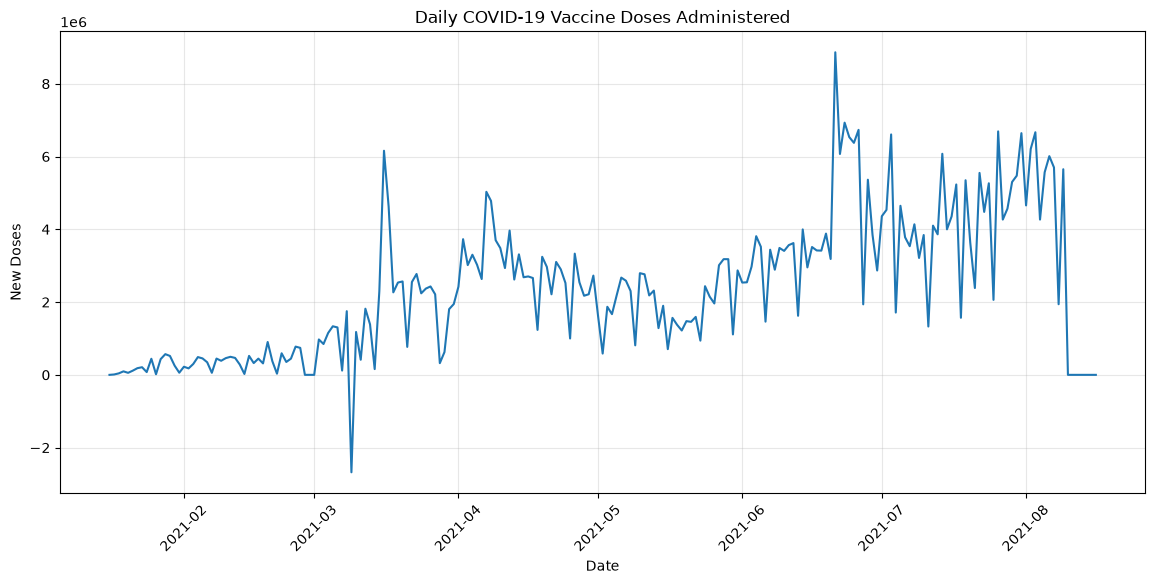

In [10]:
daily_new_doses = (
    vaccine_states
    .groupby("Updated On")["NewDoses"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(daily_new_doses)

plt.title("Daily COVID-19 Vaccine Doses Administered")
plt.xlabel("Date")
plt.ylabel("New Doses")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

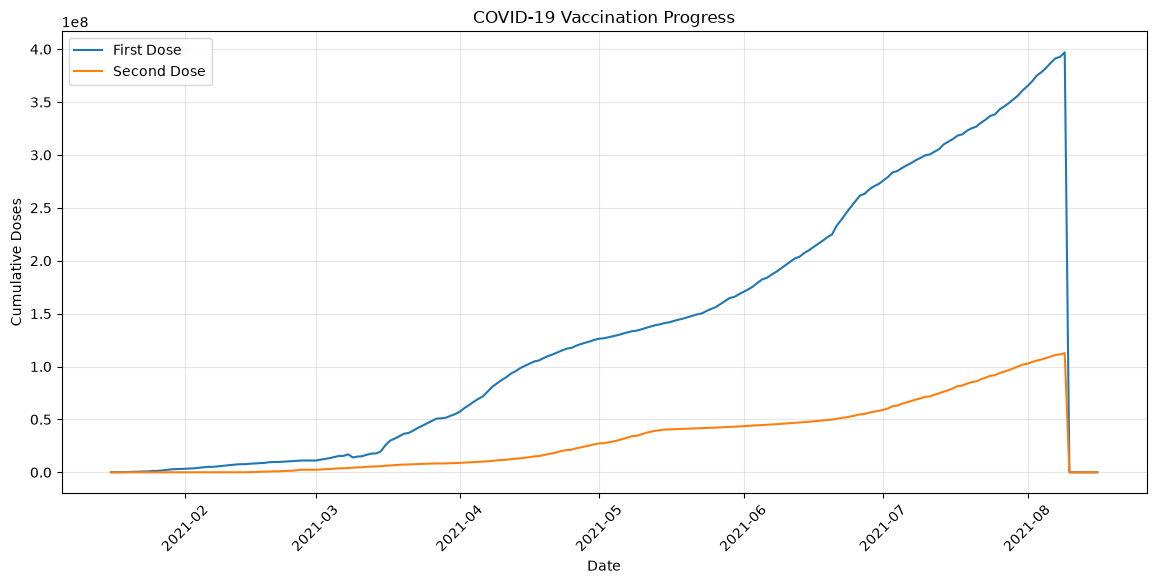

In [11]:
daily_first_dose = (
    vaccine_states
    .groupby("Updated On")["First Dose Administered"]
    .sum()
    .sort_index()
)

daily_second_dose = (
    vaccine_states
    .groupby("Updated On")["Second Dose Administered"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(daily_first_dose, label="First Dose")
plt.plot(daily_second_dose, label="Second Dose")

plt.title("COVID-19 Vaccination Progress")
plt.xlabel("Date")
plt.ylabel("Cumulative Doses")

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

the state vaccination leaders

In [ ]:
latest_vaccine = (
    vaccine_states
    .dropna(subset=["Total Doses Administered"])
    .sort_values("Updated On")
    .groupby("State")
    .tail(1)
)

state_vaccination = (
    latest_vaccine[
        ["State", "Total Doses Administered"]
    ]
    .sort_values(
        "Total Doses Administered",
        ascending=False
    )
)

display(state_vaccination.head(10))

,State,Total Doses Administered
4028,Ladakh,NaN
7420,Uttar Pradesh,NaN
3180,Jammu and Kashmir,NaN
2968,Himachal Pradesh,NaN
2756,Haryana,NaN
2544,Gujarat,NaN
2332,Goa,NaN
3392,Jharkhand,NaN
1907,Dadra and Nagar Haveli and Daman and Diu,NaN
1483,Chandigarh,NaN


In [14]:
vaccination_summary = (
    vaccine_states
    .dropna(subset=["Total Doses Administered"])
    .groupby("Updated On")["Total Doses Administered"]
    .sum()
    .sort_index()
)

check_dates = [
    "2021-02-01",
    "2021-03-01",
    "2021-04-01",
    "2021-05-01",
    "2021-06-01",
    "2021-07-01",
    "2021-07-31"
]

for date in check_dates:
    date = pd.Timestamp(date)

    available = vaccination_summary[
        vaccination_summary.index <= date
    ]

    if len(available) > 0:
        value = available.iloc[-1]
        print(date.date(), ":", f"{value:,.0f}")

2021-02-01 : 3,350,260
2021-03-01 : 13,560,812
2021-04-01 : 66,237,441
2021-05-01 : 153,626,325
2021-06-01 : 214,314,522
2021-07-01 : 334,913,220
2021-07-31 : 463,113,439


In [15]:
print("Missing Total Doses:",
      vaccine_states["Total Doses Administered"].isna().sum())

print("Negative New Doses:",
      (vaccine_states["NewDoses"] < 0).sum())

print("Zero New Doses:",
      (vaccine_states["NewDoses"] == 0).sum())

Missing Total Doses: 218
Negative New Doses: 56
Zero New Doses: 218


Vaccination began in January 2021.
First-dose coverage increased substantially.
Second-dose coverage increased more gradually.
Some cumulative vaccination records contain revisions/missing values.
Therefore, vaccination variables need cleaning before integration.

## Key Findings

1. COVID-19 cases in India exhibited two major waves during the study period. The first wave reached a 7-day average peak of approximately 93,199 reported cases on 17 September 2020, while the second wave peaked at approximately 391,280 cases on 9 May 2021.

2. The second wave was approximately 4.2 times larger than the first wave based on the 7-day average of reported cases.

3. The 7-day average of reported deaths peaked at approximately 4,190 on 24 May 2021.

4. COVID-19 testing volume increased substantially over the study period. However, the Positive field contains substantial missing data, particularly in the later period, limiting its reliability for direct positivity-rate analysis.

5. Vaccination expanded considerably from January through July 2021. The aggregated cumulative number of doses increased substantially during this period, although the vaccination dataset contains missing values and reporting revisions.

6. The datasets contain inconsistent state names and special categories that must be standardized before spatial analysis and dataset integration.